In [ ]:
"""
Implementation of Parallelized Extreme Learning Machine (P-ELM)
Target: Online Data Classification & DevOps Anomaly Detection

Author: Amanda Taheri
Based on the research paper:
Title: Parallelized Extreme Learning Machine for Online Data Classification
https://doi.org/10.1007/s10489-022-03308-7
Copyright (c) 2026. All rights reserved.

"""

In [1]:
import sys
import os
import numpy as np
import time
import matplotlib.pyplot as plt

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.elm_svd import ELMSVD      # Single-core (Serial)
from src.elm_parallel import ParallelELM # Multi-core (Parallel)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("Ready to test Parallel Performance!")


Ready to test Parallel Performance!


In [2]:
def generate_big_devops_data(n_samples=50000):
    # Simulating 10 features for more complexity
    np.random.seed(42)
    X = np.random.randn(n_samples, 10)
    # Target: Simple non-linear relation
    y = (np.sin(X[:, 0]) + X[:, 1]**2 > 1.5).astype(int)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return train_test_split(X_scaled, y, test_size=0.2)

X_train, X_test, y_train, y_test = generate_big_devops_data()
print(f"Dataset Size: {X_train.shape[0]} training samples.")


Dataset Size: 40000 training samples.


In [3]:
# Model Parameters
hidden = 500 # Using more neurons to increase computational load

# 1. Test Serial ELM (Phase 2)
start_time = time.time()
serial_model = ELMSVD(input_size=10, hidden_size=hidden)
serial_model.fit(X_train, y_train)
serial_time = time.time() - start_time
print(f"Serial Training Time: {serial_time:.4f} seconds")

# 2. Test Parallel ELM (Phase 3)
# We use 4 workers (adjust based on your CPU cores)
start_time = time.time()
parallel_model = ParallelELM(input_size=10, hidden_size=hidden, n_workers=4)
parallel_model.fit(X_train, y_train)
parallel_time = time.time() - start_time
print(f"Parallel Training Time: {parallel_time:.4f} seconds")

speedup = serial_time / parallel_time
print(f"\n Speedup Factor: {speedup:.2f}x faster!")


Serial Training Time: 0.8810 seconds
Parallel Training Time: 0.6494 seconds

 Speedup Factor: 1.36x faster!


Serial Accuracy: 77.11%
Parallel Accuracy: 79.01%


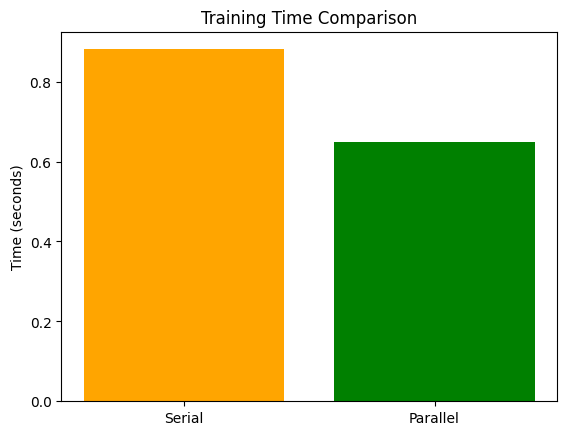

In [4]:
from sklearn.metrics import accuracy_score

serial_acc = accuracy_score(y_test, (serial_model.predict(X_test) > 0.5))
parallel_acc = accuracy_score(y_test, (parallel_model.predict(X_test) > 0.5))

print(f"Serial Accuracy: {serial_acc*100:.2f}%")
print(f"Parallel Accuracy: {parallel_acc*100:.2f}%")

# Plotting
plt.bar(['Serial', 'Parallel'], [serial_time, parallel_time], color=['orange', 'green'])
plt.ylabel('Time (seconds)')
plt.title('Training Time Comparison')
plt.show()
